<a href="https://colab.research.google.com/github/dr-dlr/drlab/blob/hackathon/hackathon_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando libs

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

# TRANSACCIONES Limpieza y revisado de datos

In [34]:
# asignando una variable al dataset
transacciones = pd.read_csv('/content/transactions.csv')

In [35]:
# revisando brevemente las columnas
transacciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119465 entries, 0 to 119464
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           119465 non-null  int64  
 1   user_id                  119465 non-null  int64  
 2   fecha_transaccion        119465 non-null  object 
 3   descripcion_transaccion  119465 non-null  object 
 4   monto_transaccion        119465 non-null  float64
 5   medio_pago               119465 non-null  object 
 6   edad                     119465 non-null  int64  
 7   sexo                     119465 non-null  object 
 8   ingreso_mensual          119465 non-null  int64  
 9   linea_credito            119465 non-null  int64  
 10  credito_utilizado        119465 non-null  int64  
 11  frecuencia_ahorro        119465 non-null  object 
 12  categoria_gasto          119465 non-null  object 
dtypes: float64(1), int64(6), object(6)
memory usage: 11.8+ MB


In [36]:
# revisando brevemente el contenido
transacciones.head(5)

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
0,1,1,2025-10-30,Soriana,1072.15,Debito,58,M,37256,30000,24132,Baja,Alimentacion
1,2,1,2025-04-22,Soriana,604.67,Debito,58,M,37256,30000,24132,Baja,Alimentacion
2,3,1,2025-04-12,Farmacias del Ahorro,1798.57,Transferencia,58,M,37256,30000,24132,Baja,Salud
3,4,1,2025-08-18,Uber,1485.49,Debito,58,M,37256,30000,24132,Baja,Transporte
4,5,1,2025-12-24,OXXO,1073.86,Efectivo,58,M,37256,30000,24132,Baja,Alimentacion


In [37]:
# Revisando las categorías en 'categoria_gasto'
print (transacciones['categoria_gasto'].unique())
print (f'Se encuentran ausentes dos categorías: "Vivienda y Educación')

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento']
Se encuentran ausentes dos categorías: "Vivienda y Educación


In [38]:
# Añadiendo las categorías que faltaban de acuerdo con el desafío (educación y vivienda)

import numpy as np
import random

# Obtener todos los IDs de usuario únicos
unique_users = transacciones['user_id'].unique()

new_rows = []

for user in unique_users:
    # Datos base del usuario (asumiendo que edad, sexo, ingreso, etc. son constantes por usuario)
    user_info = transacciones[transacciones['user_id'] == user].iloc[0]

    # 1. Transacción de Vivienda
    new_rows.append({
        'transaction_id': 0, # Se resetearán después
        'user_id': user,
        'fecha_transaccion': '2025-06-15',
        'descripcion_transaccion': random.choice(['Home Depot', 'Interceramic']),
        'monto_transaccion': round(random.uniform(500, 5000), 2),
        'medio_pago': random.choice(['Debito', 'Credito', 'Transferencia']),
        'edad': user_info['edad'],
        'sexo': user_info['sexo'],
        'ingreso_mensual': user_info['ingreso_mensual'],
        'linea_credito': user_info['linea_credito'],
        'credito_utilizado': user_info['credito_utilizado'],
        'frecuencia_ahorro': user_info['frecuencia_ahorro'],
        'categoria_gasto': 'Vivienda'
    })

    # 2. Transacción de Educación
    new_rows.append({
        'transaction_id': 0,
        'user_id': user,
        'fecha_transaccion': '2025-07-20',
        'descripcion_transaccion': random.choice(['Librerías Gandhi', 'Proveedora Escolar']),
        'monto_transaccion': round(random.uniform(200, 1500), 2),
        'medio_pago': random.choice(['Debito', 'Credito', 'Efectivo']),
        'edad': user_info['edad'],
        'sexo': user_info['sexo'],
        'ingreso_mensual': user_info['ingreso_mensual'],
        'linea_credito': user_info['linea_credito'],
        'credito_utilizado': user_info['credito_utilizado'],
        'frecuencia_ahorro': user_info['frecuencia_ahorro'],
        'categoria_gasto': 'Educacion'
    })

# Crear DataFrame con nuevas filas y concatenar
df_nuevos = pd.DataFrame(new_rows)
transacciones = pd.concat([transacciones, df_nuevos], ignore_index=True)

# Recalcular transaction_id para que sea único
transacciones['transaction_id'] = range(1, len(transacciones) + 1)

print(f'Se añadieron {len(df_nuevos)} nuevas filas.')
display(transacciones.tail(3))

Se añadieron 6000 nuevas filas.


,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,edad,sexo,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,categoria_gasto
125462,125463,2999,2025-07-20,Proveedora Escolar,1474.61,Credito,54,M,41035,30000,23407,Alta,Educacion
125463,125464,3000,2025-06-15,Home Depot,579.64,Transferencia,46,F,58563,30000,13664,Media,Vivienda
125464,125465,3000,2025-07-20,Librerías Gandhi,1310.62,Efectivo,46,F,58563,30000,13664,Media,Educacion


In [39]:
# ya aparecen las categorías que faltaban en el set original

print (transacciones['categoria_gasto'].unique())
print (f'Ya se encuentran las 8 categorías')

['Alimentacion' 'Salud' 'Transporte' 'Compras' 'Servicios'
 'Entretenimiento' 'Vivienda' 'Educacion']
Ya se encuentran las 8 categorías


In [40]:
transacciones.columns

Index(['transaction_id', 'user_id', 'fecha_transaccion',
       'descripcion_transaccion', 'monto_transaccion', 'medio_pago', 'edad',
       'sexo', 'ingreso_mensual', 'linea_credito', 'credito_utilizado',
       'frecuencia_ahorro', 'categoria_gasto'],
      dtype='object')

In [41]:
transacciones.to_csv('transacciones_ok.csv', index=False)

In [42]:
# Eliminando las variables que no sirven para este dataset

transacciones_ok = transacciones.drop(['edad', 'sexo', 'ingreso_mensual', 'linea_credito', 'credito_utilizado', 'frecuencia_ahorro'], axis = 1)

In [43]:
transacciones_ok.columns

Index(['transaction_id', 'user_id', 'fecha_transaccion',
       'descripcion_transaccion', 'monto_transaccion', 'medio_pago',
       'categoria_gasto'],
      dtype='object')

In [44]:
# Pasando todo el texto a minúsculas

text_columns = transacciones_ok.select_dtypes(include=['object']).columns

for col in text_columns:
    transacciones_ok[col] = transacciones_ok[col].str.lower()

display(transacciones_ok.head())

,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto
0,1,1,2025-10-30,soriana,1072.15,debito,alimentacion
1,2,1,2025-04-22,soriana,604.67,debito,alimentacion
2,3,1,2025-04-12,farmacias del ahorro,1798.57,transferencia,salud
3,4,1,2025-08-18,uber,1485.49,debito,transporte
4,5,1,2025-12-24,oxxo,1073.86,efectivo,alimentacion


In [45]:
transacciones_ok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125465 entries, 0 to 125464
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           125465 non-null  int64  
 1   user_id                  125465 non-null  int64  
 2   fecha_transaccion        125465 non-null  object 
 3   descripcion_transaccion  125465 non-null  object 
 4   monto_transaccion        125465 non-null  float64
 5   medio_pago               125465 non-null  object 
 6   categoria_gasto          125465 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 6.7+ MB


In [46]:
transacciones_ok.isnull().sum()

,0
transaction_id,0
user_id,0
fecha_transaccion,0
descripcion_transaccion,0
monto_transaccion,0
medio_pago,0
categoria_gasto,0


In [47]:
transacciones_ok.duplicated().sum()

np.int64(0)

NO EXISTEN DATOS NULOS, DUPLICADOS, EN MAYÚSCULAS NI FALTANTES

# TRANSACCIONES Exploración de datos

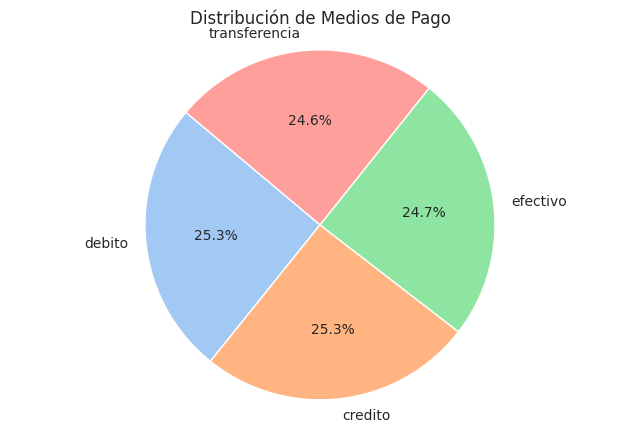

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

distribucion_pagos = transacciones_ok['medio_pago'].value_counts()

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.pie(distribucion_pagos,
        labels=distribucion_pagos.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Distribución de Medios de Pago')
plt.axis('equal')
plt.show()

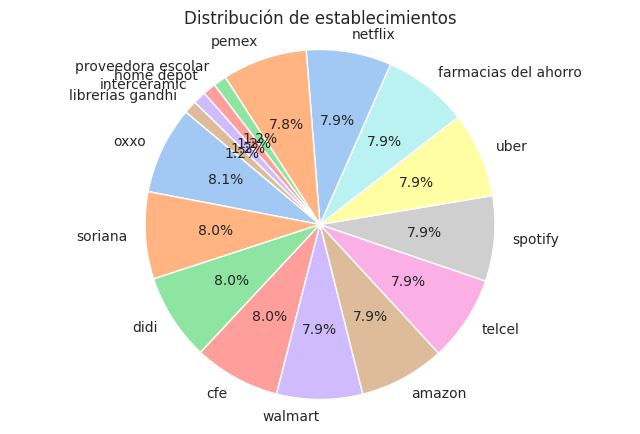

In [49]:
distribucion_negocios = transacciones_ok['descripcion_transaccion'].value_counts()

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.pie(distribucion_negocios,
        labels=distribucion_negocios.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Distribución de establecimientos')
plt.axis('equal')
plt.show()

# CLIENTES Limpieza y revisado de datos

In [50]:
clientes = pd.read_csv('/content/users.csv')
clientes.head(3)

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,M,Soltero,2,0,37256,30000,24132,Baja,1117.68,En riesgo
1,2,31,M,Divorciado,1,1,61354,30000,3090,Baja,1840.62,En observacion
2,3,29,F,Divorciado,1,1,28866,15000,6267,Alta,6350.52,En observacion


In [51]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                3000 non-null   int64  
 1   edad                   3000 non-null   int64  
 2   sexo                   3000 non-null   object 
 3   estado_civil           3000 non-null   object 
 4   numero_hijos           3000 non-null   int64  
 5   empleo_formal          3000 non-null   int64  
 6   ingreso_mensual        3000 non-null   int64  
 7   linea_credito          3000 non-null   int64  
 8   credito_utilizado      3000 non-null   int64  
 9   frecuencia_ahorro      3000 non-null   object 
 10  monto_promedio_ahorro  3000 non-null   float64
 11  perfil_financiero      3000 non-null   object 
dtypes: float64(1), int64(7), object(4)
memory usage: 281.4+ KB


In [52]:
clientes.columns

Index(['user_id', 'edad', 'sexo', 'estado_civil', 'numero_hijos',
       'empleo_formal', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro',
       'perfil_financiero'],
      dtype='object')

In [53]:
print (f'Las columnas de transacciones son {transacciones_ok.columns}')
print (f'Las columnas de clientes son {clientes.columns}')

Las columnas de transacciones son Index(['transaction_id', 'user_id', 'fecha_transaccion',
       'descripcion_transaccion', 'monto_transaccion', 'medio_pago',
       'categoria_gasto'],
      dtype='object')
Las columnas de clientes son Index(['user_id', 'edad', 'sexo', 'estado_civil', 'numero_hijos',
       'empleo_formal', 'ingreso_mensual', 'linea_credito',
       'credito_utilizado', 'frecuencia_ahorro', 'monto_promedio_ahorro',
       'perfil_financiero'],
      dtype='object')


In [54]:
text_columns_clientes = clientes.select_dtypes(include=['object']).columns

for col in text_columns_clientes:
    clientes[col] = clientes[col].str.lower()

display(clientes.head())

,user_id,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,58,m,soltero,2,0,37256,30000,24132,baja,1117.68,en riesgo
1,2,31,m,divorciado,1,1,61354,30000,3090,baja,1840.62,en observacion
2,3,29,f,divorciado,1,1,28866,15000,6267,alta,6350.52,en observacion
3,4,19,f,unión libre,3,0,69261,30000,20390,media,6926.10,en riesgo
4,5,62,m,divorciado,0,0,45268,80000,62746,media,4526.80,en riesgo


In [55]:
clientes.isnull().sum()

,0
user_id,0
edad,0
sexo,0
estado_civil,0
numero_hijos,0
empleo_formal,0
ingreso_mensual,0
linea_credito,0
credito_utilizado,0
frecuencia_ahorro,0


In [56]:
clientes.duplicated().sum()

np.int64(0)

NO EXISTEN VALORES NULOS NI DUPLICADOS EN EL DATASET DE CLIENTES

# UNIENDO ambos datasets

In [57]:
# Realizando el merge de los datasets por user_id
df_final = pd.merge(transacciones_ok, clientes, on='user_id', how='inner')

# Verificando el resultado
print(f'Dimensiones del nuevo dataset: {df_final.shape}')
display(df_final.head(1))

Dimensiones del nuevo dataset: (125465, 18)


,transaction_id,user_id,fecha_transaccion,descripcion_transaccion,monto_transaccion,medio_pago,categoria_gasto,edad,sexo,estado_civil,numero_hijos,empleo_formal,ingreso_mensual,linea_credito,credito_utilizado,frecuencia_ahorro,monto_promedio_ahorro,perfil_financiero
0,1,1,2025-10-30,soriana,1072.15,debito,alimentacion,58,m,soltero,2,0,37256,30000,24132,baja,1117.68,en riesgo


# Matriz de correlación entre variables usando Spearman

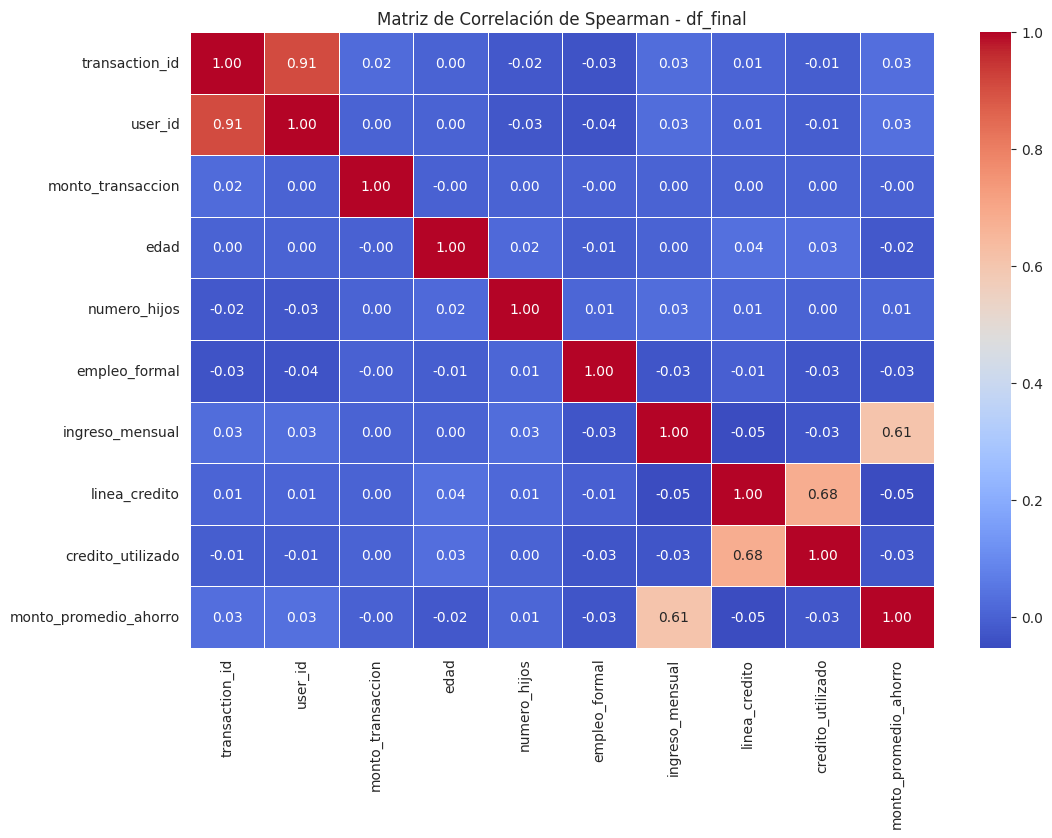

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos solo las columnas numéricas para la correlación
columnas_numericas = df_final.select_dtypes(include=['float64', 'int64'])

# Calculamos la matriz de correlación de Spearman
corr_matrix = columnas_numericas.corr(method='spearman')

# Configuramos el estilo visual
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación de Spearman - df_final')
plt.show()